In [40]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np

In [41]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(199)

In [42]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

class CubeCylinderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
    
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        
        cube_path = os.path.join(root_dir, "fCube_Images")
        cylinder_path = os.path.join(root_dir, "fCylinder_Images")
        

        for file in os.listdir(cube_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                self.samples.append(
                    (os.path.join(cube_path, file), 0)
                )
        
        for file in os.listdir(cylinder_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                self.samples.append(
                    (os.path.join(cylinder_path, file), 1)
                )
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
    

In [43]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = CubeCylinderDataset(root_dir=".", transform=transform)

print("Total de imagens:", len(dataset))
img, label = dataset[0]
print("Shape:", img.shape, "Label:", label)

Total de imagens: 2000
Shape: torch.Size([3, 128, 128]) Label: 0


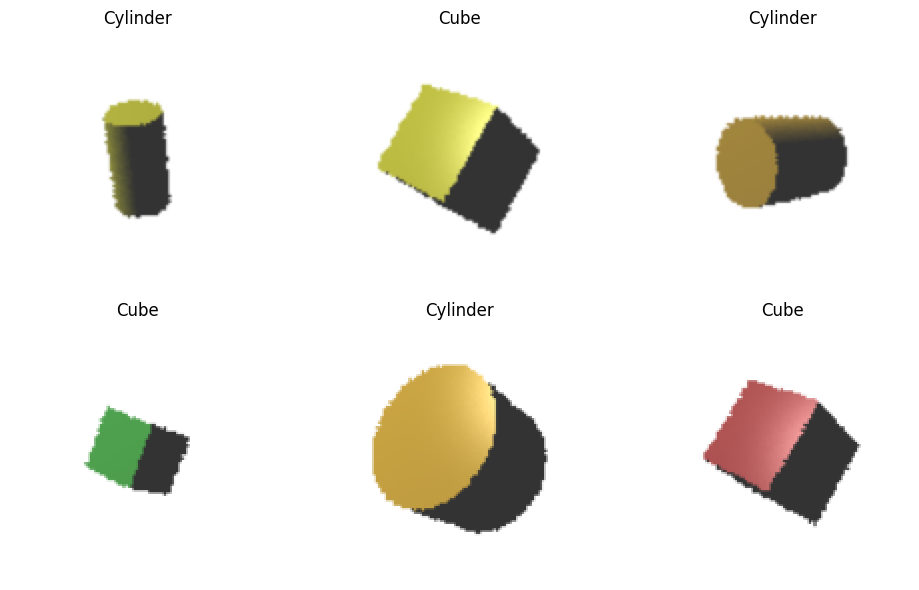

In [44]:
import numpy as np
import matplotlib.pyplot as plt

num_examples = 6
randomlist = np.random.randint(0, len(dataset), size=num_examples)

plt.figure(figsize=(10, 6))

for plot_idx, data_idx in enumerate(randomlist):
    img, label = dataset[data_idx]
    
    img = img.permute(1, 2, 0)
    
    plt.subplot(2, 3, plot_idx + 1)
    plt.imshow(img)
    plt.title("Cube" if label == 0 else "Cylinder")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
from SupervisedVAE import sGuidedVAE

from torch.utils.data import DataLoader, random_split

dataset_size = len(dataset)


train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [64]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torch.optim import Adam

def train_supervised(epoch, model, model_c,
                           optimizer, optimizer_c,
                           dataloader, w_internal, w_adv, device):

    model.train()
    model_c.train()

    re_loss = 0
    kld_loss = 0
    cls_internal_error = 0
    cls_aux_error = 0
    cls_adv_error = 0

    correct_internal = 0
    correct_aux = 0
    correct_adv = 0

    for batch_idx, (data, label) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch}")):

        data = data.to(device)
        label = label.float().unsqueeze(1).to(device)

        # =========================================================
        # 1️⃣ TREINA O VAE (Reconstrução + Cls Interna + Enganar model_c)
        # =========================================================
        optimizer.zero_grad()

        # Forward do VAE
        recon_batch, mu, logvar, cls_out = model(data)
        z = model.reparameterize(mu, logvar)

        # Losses normais do VAE
        MSE = F.mse_loss(recon_batch, data, reduction="sum")
        MSE = F.l1_loss(recon_batch, data, reduction="sum")
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        
        # Loss do classificador interno (acertar a classe)
        loss_cls_internal = F.binary_cross_entropy(cls_out, label, reduction='sum')

        # Loss Adversarial: passamos o z[:, 1:] no model_c para o VAE tentar ENGANÁ-LO
        z_aux = z[:, 1:]
        cls2 = model_c(z_aux)
        
        # O VAE quer que o classificador preveja 0.5 (incerteza total)
        neutral_label = torch.full_like(label, 0.5)
        loss_adv = F.binary_cross_entropy(cls2, neutral_label, reduction='sum')

        # SOMA TODAS AS LOSSES DO VAE! Aqui a mágica acontece.
        loss_vae_total = MSE + KLD + (w_internal * loss_cls_internal) + (w_adv * loss_adv)

        loss_vae_total.backward()
        optimizer.step()

        # Guarda as métricas do VAE
        re_loss += MSE.item()
        kld_loss += KLD.item()
        cls_internal_error += loss_cls_internal.item()
        cls_adv_error += loss_adv.item()

        # =========================================================
        # 2️⃣ TREINA O CLASSIFICADOR AUXILIAR (model_c)
        # =========================================================
        optimizer_c.zero_grad()

        # Usamos o z que já foi calculado, mas com .detach()!
        # Isso impede que a atualização do classificador afete os pesos do VAE.
        z_aux_detached = z[:, 1:].detach()
        
        # Forward no classificador auxiliar
        cls1 = model_c(z_aux_detached)
        
        # O classificador auxiliar quer ACERTAR a classe real
        loss_aux = F.binary_cross_entropy(cls1, label, reduction='sum')
        
        loss_aux.backward()
        optimizer_c.step()

        # Guarda as métricas do Classificador Auxiliar
        cls_aux_error += loss_aux.item()

        # =========================================================
        # Acurácias
        # =========================================================
        # Acurácia do classificador interno (VAE)
        pred_internal = (cls_out > 0.5).float()
        correct_internal += pred_internal.eq(label).sum().item()

        # Acurácia do classificador auxiliar (tentando acertar de verdade)
        pred_aux = (cls1 > 0.5).float()
        correct_aux += pred_aux.eq(label).sum().item()

        # Acurácia de como o classificador se saiu ANTES do VAE ser atualizado
        # (usamos cls2, que foi calculado no passo 1)
        pred_adv = (cls2 > 0.5).float()
        correct_adv += pred_adv.eq(label).sum().item()

    # =========================================================
    # Print dos Resultados da Época
    # =========================================================
    N = len(dataloader.dataset)

    print(f'''
====> Epoch {epoch}
Recon Loss: {re_loss/N:.4f} | KLD: {kld_loss/N:.4f}
Cls (internal): {cls_internal_error/N:.4f} | Acc: {100*correct_internal/N:.2f}%
Cls Auxiliar (model_c aprendendo): {cls_aux_error/N:.4f} | Acc1: {100*correct_aux/N:.2f}%
Cls Adversarial (VAE enganando): {cls_adv_error/N:.4f} | Acc2: {100*correct_adv/N:.2f}%
''')


In [47]:
def train_supervised(epoch, model, model_c,
                     optimizer, optimizer_c,
                     dataloader, w_internal, w_adv, device):

    model.train()
    model_c.train()

    re_loss = 0
    kld_loss = 0
    cls_internal_error = 0
    cls_aux_error = 0
    cls_adv_error = 0

    correct_internal = 0
    correct_aux = 0
    correct_adv = 0

    for batch_idx, (data, label) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch}")):

        data = data.to(device)
        label = label.float().unsqueeze(1).to(device)

        # =========================================================
        # 1️⃣ TREINA VAE (recon + KL + cls interna)
        # =========================================================
        optimizer.zero_grad()

        recon_batch, mu, logvar, cls_out = model(data)

        MSE = F.mse_loss(recon_batch, data, reduction="sum")
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        loss_cls_internal = F.binary_cross_entropy(cls_out, label, reduction='sum')

        loss_vae = MSE + KLD + w_internal * loss_cls_internal

        loss_vae.backward()
        optimizer.step()

        re_loss += MSE.item()
        kld_loss += KLD.item()
        cls_internal_error += loss_cls_internal.item()

        # =========================================================
        # 2️⃣ TREINA CLASSIFICADOR AUXILIAR (prever label de z[1:])
        # =========================================================
        optimizer_c.zero_grad()

        with torch.no_grad():
            mu, logvar = model.encode(data)
            z = model.reparameterize(mu, logvar)

        z_aux = z[:, 1:]
        cls1 = model_c(z_aux)

        loss_aux = F.binary_cross_entropy(cls1, label, reduction='sum')

        loss_aux.backward()
        optimizer_c.step()

        cls_aux_error += loss_aux.item()

        # =========================================================
        # 3️⃣ TREINA ENCODER PARA ENGANAR CLASSIFICADOR
        # =========================================================
        optimizer.zero_grad()

        mu, logvar = model.encode(data)
        z = model.reparameterize(mu, logvar)

        z_aux = z[:, 1:]
        cls2 = model_c(z_aux)

        neutral_label = torch.full_like(label, 0.5)

        loss_adv = F.binary_cross_entropy(cls2, neutral_label, reduction='sum')

        (w_adv * loss_adv).backward()
        optimizer.step()

        cls_adv_error += loss_adv.item()

        # =========================================================
        # Acurácias
        # =========================================================
        pred_internal = (cls_out > 0.5).float()
        correct_internal += pred_internal.eq(label).sum().item()

        pred_aux = (cls1 > 0.5).float()
        correct_aux += pred_aux.eq(label).sum().item()

        pred_adv = (cls2 > 0.5).float()
        correct_adv += pred_adv.eq(label).sum().item()

    # =========================================================
    # Print
    # =========================================================
    N = len(dataloader.dataset)

    print(f'''
====> Epoch {epoch}
Recon Loss: {re_loss/N:.4f} | KLD: {kld_loss/N:.4f}
Cls (internal): {cls_internal_error/N:.4f} | Acc: {100*correct_internal/N:.2f}%
Cls Auxiliar: {cls_aux_error/N:.4f} | Acc1: {100*correct_aux/N:.2f}%
Cls Adversarial: {cls_adv_error/N:.4f} | Acc2: {100*correct_adv/N:.2f}%
''')

In [65]:
def train_supervised(epoch, model, model_c,
                     optimizer, optimizer_c,
                     dataloader, w_internal, w_adv, device):

    model.train()
    model_c.train()

    re_loss = 0
    kld_loss = 0
    cls_internal_error = 0
    cls_aux_error = 0
    cls_adv_error = 0

    correct_internal = 0
    correct_aux = 0
    correct_adv = 0

    for batch_idx, (data, label) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch}")):

        data = data.to(device)
        label = label.float().unsqueeze(1).to(device)

        # =====================================================
        # 1️⃣ TREINA VAE (recon + KL + classificador interno)
        # =====================================================

        optimizer.zero_grad()

        recon_batch, mu, logvar, cls_out = model(data)

        MSE = F.mse_loss(recon_batch, data, reduction="sum")
        MSE = F.l1_loss(recon_batch, data, reduction="sum")
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        loss_cls_internal = F.binary_cross_entropy(cls_out, label, reduction='sum')

        loss_vae = MSE + KLD + w_internal * loss_cls_internal

        loss_vae.backward()
        optimizer.step()

        re_loss += MSE.item()
        kld_loss += KLD.item()
        cls_internal_error += loss_cls_internal.item()

        # =====================================================
        # 2️⃣ TREINA CLASSIFICADOR AUXILIAR
        # =====================================================

        optimizer_c.zero_grad()

        with torch.no_grad():
            mu, logvar = model.encode(data)

        z_aux = mu[:,1:]   # 🔑 usa MU (mais estável)

        cls1 = model_c(z_aux)

        loss_aux = F.binary_cross_entropy(cls1, label, reduction='sum')

        loss_aux.backward()
        optimizer_c.step()

        cls_aux_error += loss_aux.item()

        # =====================================================
        # 3️⃣ TREINA ENCODER ADVERSARIALMENTE
        # =====================================================

        optimizer.zero_grad()

        mu, logvar = model.encode(data)

        z_aux = mu[:,1:]   # 🔑 usa MU novamente

        cls2 = model_c(z_aux)

        neutral_label = torch.full_like(label, 0.5)

        loss_adv = F.binary_cross_entropy(cls2, neutral_label, reduction='sum')

        (w_adv * loss_adv).backward()
        optimizer.step()

        cls_adv_error += loss_adv.item()

        # =====================================================
        # Acurácias
        # =====================================================

        pred_internal = (cls_out > 0.5).float()
        correct_internal += pred_internal.eq(label).sum().item()

        pred_aux = (cls1 > 0.5).float()
        correct_aux += pred_aux.eq(label).sum().item()

        pred_adv = (cls2 > 0.5).float()
        correct_adv += pred_adv.eq(label).sum().item()

    # =====================================================
    # PRINT
    # =====================================================

    N = len(dataloader.dataset)

    print(f'''
====> Epoch {epoch}
Recon Loss: {re_loss/N:.4f} | KLD: {kld_loss/N:.4f}

Cls Internal:
Loss {cls_internal_error/N:.4f}
Acc  {100*correct_internal/N:.2f}%

Cls Aux (predict label from z[1:]):
Loss {cls_aux_error/N:.4f}
Acc  {100*correct_aux/N:.2f}%

Cls Adv (encoder confusion):
Loss {cls_adv_error/N:.4f}
Acc  {100*correct_adv/N:.2f}%
''')

In [66]:
class LatentClassifier(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim-1, 32),  # remove primeira dimensão
            nn.ReLU(True),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)


In [ ]:
from torch.optim import Adam
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 4
model = sGuidedVAE(latent_dim=latent_dim).to(device)
model_c = LatentClassifier(latent_dim).to(device)

optimizer = Adam(model.parameters(), lr=1e-3)
optimizer_c = Adam(model_c.parameters(), lr=1e-3)

w_cls = 5.0
epochs = 50


# =========================================================
# Setup e Loop Principal
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 4
# Substitua pelas chamadas reais dos seus modelos
# model = sGuidedVAE(latent_dim=latent_dim).to(device)
# model_c = LatentClassifier(latent_dim).to(device)

optimizer = Adam(model.parameters(), lr=1e-3)
optimizer_c = Adam(model_c.parameters(), lr=1e-3)

# Pesos muito mais realistas!
w_internal = 10.0  # Peso para o VAE acertar a classe interna
w_adv = 15.0       # Peso para o VAE destruir a informação de classe em z[:, 1:]
epochs = 50

for epoch in range(1, epochs + 1):
    train_supervised(
        epoch=epoch,
        model=model, 
        model_c=model_c,
        optimizer=optimizer, 
        optimizer_c=optimizer_c,
        dataloader=train_loader, # Certifique-se de que train_loader está definido
        w_internal=w_internal,
        w_adv=w_adv,
        device=device
    )

Epoch 1:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1: 100%|██████████| 50/50 [00:33<00:00,  1.50it/s]



====> Epoch 1
Recon Loss: 5881.4340 | KLD: 5168.3452

Cls Internal:
Loss 0.7740
Acc  51.12%

Cls Aux (predict label from z[1:]):
Loss 0.6724
Acc  58.62%

Cls Adv (encoder confusion):
Loss 0.7015
Acc  59.06%



Epoch 2: 100%|██████████| 50/50 [00:41<00:00,  1.21it/s]



====> Epoch 2
Recon Loss: 2793.6475 | KLD: 23.1768

Cls Internal:
Loss 0.5956
Acc  72.56%

Cls Aux (predict label from z[1:]):
Loss 0.5411
Acc  74.88%

Cls Adv (encoder confusion):
Loss 0.7650
Acc  74.94%



...


====> Epoch 48
Recon Loss: 467.0436 | KLD: 18.8417

Cls Internal:
Loss 0.0671
Acc  99.69%

Cls Aux (predict label from z[1:]):
Loss 0.3159
Acc  85.75%

Cls Adv (encoder confusion):
Loss 1.5765
Acc  85.88%



Epoch 49: 100%|██████████| 50/50 [00:54<00:00,  1.08s/it]



====> Epoch 49
Recon Loss: 475.6454 | KLD: 19.0029

Cls Internal:
Loss 0.0647
Acc  99.81%

Cls Aux (predict label from z[1:]):
Loss 0.3160
Acc  85.75%

Cls Adv (encoder confusion):
Loss 1.5786
Acc  85.69%



Epoch 50: 100%|██████████| 50/50 [00:54<00:00,  1.08s/it]


====> Epoch 50
Recon Loss: 459.2977 | KLD: 18.9173

Cls Internal:
Loss 0.0629
Acc  99.56%

Cls Aux (predict label from z[1:]):
Loss 0.3144
Acc  85.56%

Cls Adv (encoder confusion):
Loss 1.6650
Acc  85.56%



In [93]:
import matplotlib.pyplot as plt
import torch


def show_reconstructions(model, dataloader, device, n=8):
    model.eval()
    
    with torch.no_grad():
        data, label = next(iter(dataloader))
        data = data.to(device)

        recon, _, _, _ = model(data)

        data = data.cpu()
        recon = recon.cpu()

        fig, axes = plt.subplots(2, n, figsize=(2*n, 4))

        for i in range(n):
            # Original
            axes[0, i].imshow(data[i].permute(1, 2, 0))
            axes[0, i].set_title("Original")
            axes[0, i].axis("off")

            # Reconstrução
            axes[1, i].imshow(recon[i].permute(1, 2, 0))
            axes[1, i].set_title("Recon")
            axes[1, i].axis("off")

        plt.tight_layout()
        plt.show()

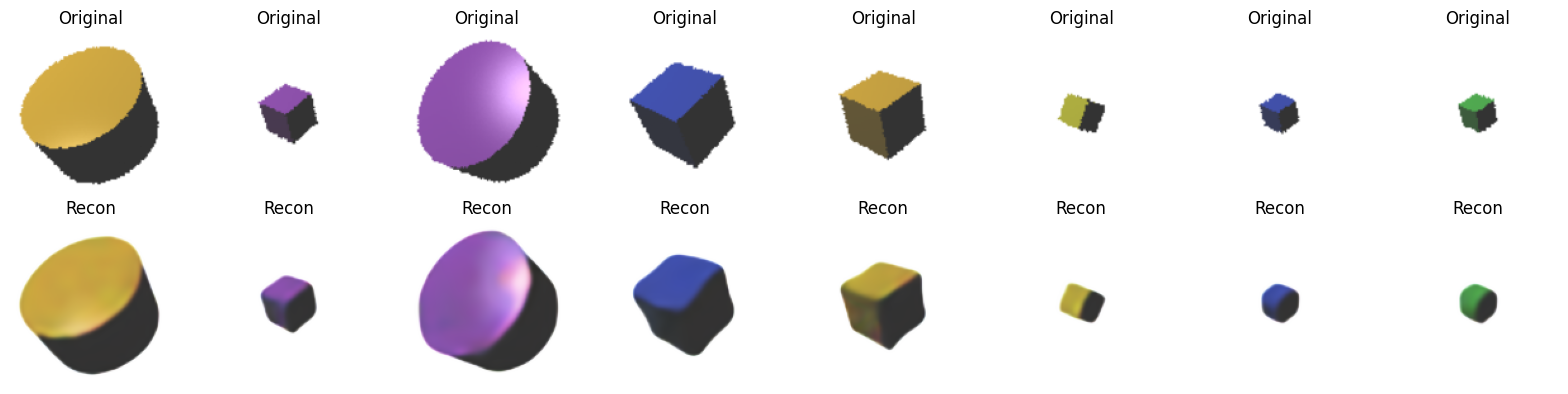

In [94]:
show_reconstructions(model, test_loader, device, n=8)

In [95]:
def extract_latents(model, dataloader, device):
    model.eval()

    cubes_latents = []
    cylinders_latents = []

    with torch.no_grad():
        for data, label in dataloader:

            data = data.to(device)
            label = label.to(device)

            mu, logvar = model.encode(data)

            for i in range(len(label)):
                if label[i] == 0:      # cubo
                    cubes_latents.append(mu[i].cpu())
                else:                  # cilindro
                    cylinders_latents.append(mu[i].cpu())

    cubes_latents = torch.stack(cubes_latents)
    cylinders_latents = torch.stack(cylinders_latents)

    return cubes_latents, cylinders_latents

In [96]:
cubes_latents, cylinders_latents = extract_latents(model, test_loader, device)

print("Cubes:", cubes_latents.shape)
print("Cylinders:", cylinders_latents.shape)

cm = cubes_latents.mean(dim= 0)
cym = cylinders_latents.mean(dim = 0)

z1 = cm
z2 = cm 

z2 -= torch.tensor([-1*0.4054, 0, 0, 0, 0 ,0 ,0 ,0])

Cubes: torch.Size([204, 8])
Cylinders: torch.Size([196, 8])


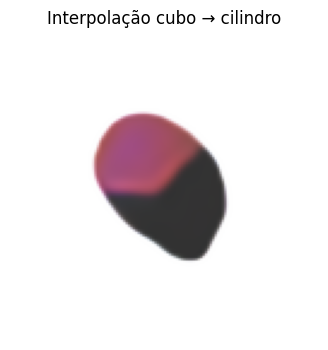

In [97]:
model.eval()

with torch.no_grad():
    z2 = z2.unsqueeze(0)
    h = model.decode(z2)

img = h[0].cpu().permute(1, 2, 0).numpy()  

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title("Interpolação cubo → cilindro")
plt.show()

In [99]:
import matplotlib.pyplot as plt
import torch

model.eval()

# média dos cubos (base latente)
base = cubes_latents.mean(dim=0)
base = torch.cat([
    cubes_latents.mean(dim=0)[:1],
    cylinders_latents.mean(dim=0)[1:]
])
# valores que vamos testar na dimensão 0
vals = torch.linspace(-1, 1, 25)

images = []

with torch.no_grad():

    for v in vals:
        z = base.clone()
        z[0] = v     # varia a dimensão da classe

        z = z.unsqueeze(0).to(device)

        img = model.decode(z)[0].cpu()
        images.append(img)

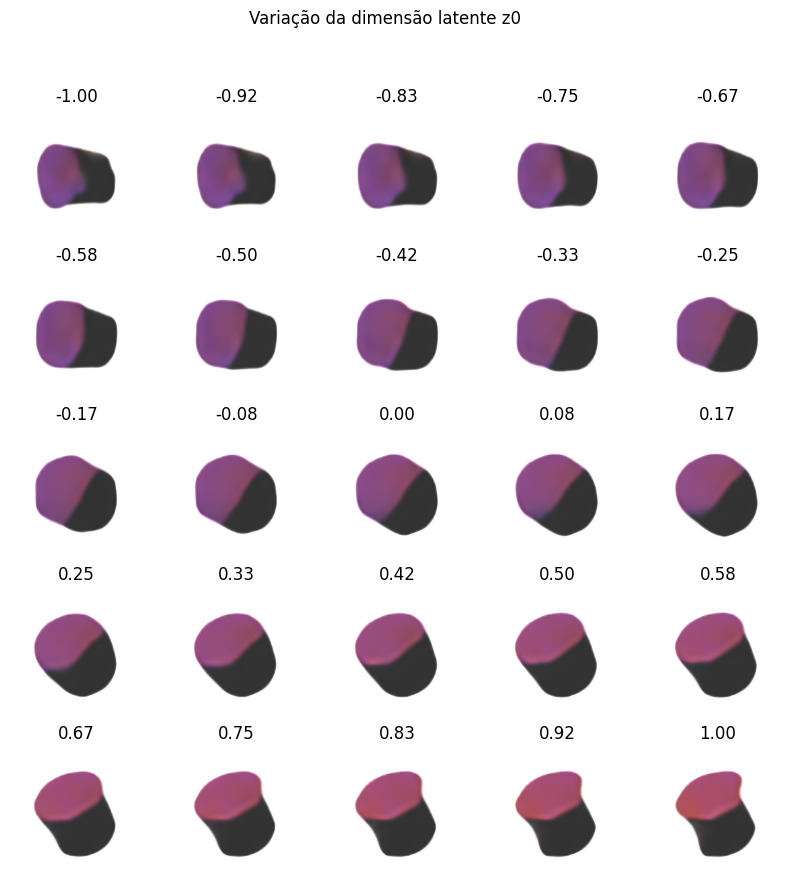

In [100]:
fig, axes = plt.subplots(5,5, figsize=(10,10))

for i, ax in enumerate(axes.flatten()):

    img = images[i].permute(1,2,0).numpy()

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{vals[i]:.2f}")

plt.suptitle("Variação da dimensão latente z0")
plt.show()